# EDA

In [90]:
#import insider_threat_clean_dataser.csv as a pandas dataframe
import pandas as pd
df = pd.read_csv('insider_threat_clean_dataset.csv')

#display the first 5 rows of the dataframe
df.head()

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,4,0,0,0.0,0,1,1,0,1,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,2,0,0,0.0,0,1,1,0,0,0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,0,0,0,0,0


In [91]:
len(df)

118614

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118614 entries, 0 to 118613
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_department          118614 non-null  object 
 1   employee_campus              118614 non-null  object 
 2   employee_position            118614 non-null  object 
 3   employee_seniority_years     118614 non-null  int64  
 4   is_contractor                118614 non-null  int64  
 5   employee_classification      118614 non-null  int64  
 6   has_foreign_citizenship      118614 non-null  int64  
 7   has_criminal_record          118614 non-null  int64  
 8   has_medical_history          118614 non-null  int64  
 9   employee_origin_country      118614 non-null  object 
 10  total_printed_pages          118614 non-null  int64  
 11  num_printed_pages_off_hours  118614 non-null  int64  
 12  total_files_burned           118614 non-null  int64  
 13 

In [93]:
#one hot encode the categorical variables
#df = pd.get_dummies(df, columns=['employee_department','employee_campus','employee_position', 'employee_origin_country'])
df.head()

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,4,0,0,0.0,0,1,1,0,1,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,2,0,0,0.0,0,1,1,0,0,0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,0,0,0,0,0


In [94]:
df.shape

(118614, 22)

In [95]:
#print pecentage of each class in the target variable
print(df['is_malicious'].value_counts(normalize=True))

is_malicious
0    0.946161
1    0.053839
Name: proportion, dtype: float64


In [96]:
#get imbalance ratio
imbalance_ratio = df['is_malicious'].value_counts()[0] / df['is_malicious'].value_counts()[1]
print(f'Imbalance Ratio: {imbalance_ratio:.2f}:1')


Imbalance Ratio: 17.57:1


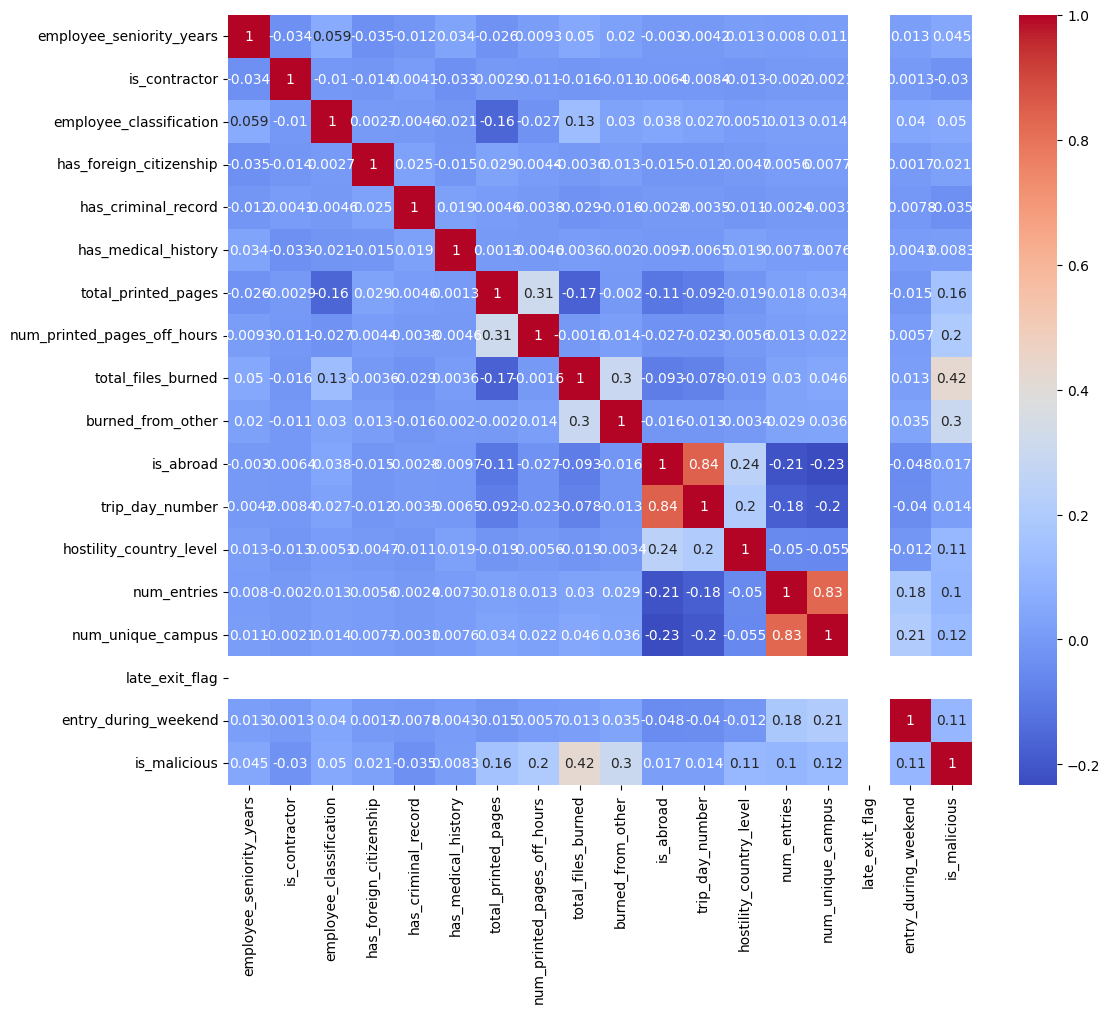

In [97]:
#correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Data Prep

In [98]:
from imblearn.over_sampling import SMOTE


In [99]:
#one hot encode the categorical variables
df = pd.get_dummies(df, columns=['employee_department','employee_campus','employee_position', 'employee_origin_country'])
df.head()

,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,...,employee_origin_country_Russia,employee_origin_country_South Africa,employee_origin_country_Sudan,employee_origin_country_Syria,employee_origin_country_Tunisia,employee_origin_country_Turkey,employee_origin_country_UK,employee_origin_country_USA,employee_origin_country_Ukraine,employee_origin_country_Yemen
0,22,0,2,0,0,0,0,0,4,0,...,False,False,False,False,False,False,False,False,False,False
1,22,0,2,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,22,0,2,0,0,0,0,0,2,0,...,False,False,False,False,False,False,False,False,False,False
3,22,0,2,0,0,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,22,0,2,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [100]:
correlations = df.corr()["is_malicious"].drop("is_malicious").abs()
top_features = correlations.nlargest(10)
print(top_features)

total_files_burned                                    0.423465
burned_from_other                                     0.297451
num_printed_pages_off_hours                           0.196895
total_printed_pages                                   0.156477
num_unique_campus                                     0.122642
employee_origin_country_China                         0.115902
hostility_country_level                               0.109457
entry_during_weekend                                  0.105110
num_entries                                           0.101549
employee_position_Integration and Testing Engineer    0.086525
Name: is_malicious, dtype: float64


In [101]:
## split data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

top_features = top_features.index.tolist()
top_features.remove("employee_origin_country_China")
top_features.remove("employee_position_Integration and Testing Engineer")
X = df[top_features]
# X = df.drop("employee_origin_country_China",axis=1)
y = df['is_malicious']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 2. Initialize SMOTE
# sampling_strategy='auto' will balance the classes 1:1
#sm = SMOTE(random_state=42)

# 3. Fit and Resample the training data
#X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)


In [102]:
import torch
import torch.nn as nn
import torch.optim as optim

In [103]:
# Detect if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [143]:


class InsiderTheatModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(InsiderTheatModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),      # Output 1 value for Binary Classification          # Squishes output between 0 and 1
        )
        
    def forward(self, x):
        return self.network(x)



In [ ]:
# 1. Prepare your data (Assuming X_train and y_train are pandas/numpy)
X_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)

# 2. Handle Imbalance: Give Class 1 (Malicious) 18x more weight
pos_weight = torch.tensor([imbalance_ratio]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) 
# Note: If using BCEWithLogitsLoss, remove the nn.Sigmoid() from the model class above!

model = InsiderTheatModel(input_size=len(top_features)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training Loop
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.3128
Epoch 50, Loss: 0.7602
Epoch 100, Loss: 0.6862
Epoch 150, Loss: 0.6530
Epoch 200, Loss: 0.6250
Epoch 250, Loss: 0.6066
Epoch 300, Loss: 0.5958
Epoch 350, Loss: 0.5899
Epoch 400, Loss: 0.5861
Epoch 450, Loss: 0.5835
Epoch 500, Loss: 0.5815
Epoch 550, Loss: 0.5799
Epoch 600, Loss: 0.5784
Epoch 650, Loss: 0.5770
Epoch 700, Loss: 0.5762
Epoch 750, Loss: 0.5752
Epoch 800, Loss: 0.5743
Epoch 850, Loss: 0.5737
Epoch 900, Loss: 0.5731
Epoch 950, Loss: 0.5729
Epoch 1000, Loss: 0.5719
Epoch 1050, Loss: 0.5712
Epoch 1100, Loss: 0.5710
Epoch 1150, Loss: 0.5702
Epoch 1200, Loss: 0.5701
Epoch 1250, Loss: 0.5692
Epoch 1300, Loss: 0.5693
Epoch 1350, Loss: 0.5687
Epoch 1400, Loss: 0.5685
Epoch 1450, Loss: 0.5678
Epoch 1500, Loss: 0.5673
Epoch 1550, Loss: 0.5673
Epoch 1600, Loss: 0.5666
Epoch 1650, Loss: 0.5664
Epoch 1700, Loss: 0.5663
Epoch 1750, Loss: 0.5660
Epoch 1800, Loss: 0.5660
Epoch 1850, Loss: 0.5656
Epoch 1900, Loss: 0.5651
Epoch 1950, Loss: 0.5647


In [151]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval() # Set to evaluation mode
with torch.no_grad():
    # 1. Get raw probabilities
    y_test_pred_logits = model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device))
    
    # 2. Convert to binary predictions (Threshold = 0.5)
    # Note: If using BCEWithLogitsLoss, apply torch.sigmoid() first
    y_test_pred = (torch.sigmoid(y_test_pred_logits) > 0.7).float().cpu().numpy()

# 3. Print the full report
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Malicious']))

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98     22463
   Malicious       0.60      0.75      0.67      1260

    accuracy                           0.96     23723
   macro avg       0.79      0.86      0.82     23723
weighted avg       0.97      0.96      0.96     23723



In [152]:
# train a neural network classifier
# from sklearn.neural_network import MLPClassifier

# model = MLPClassifier(hidden_layer_sizes=(100,100), max_iter=500, random_state=42)
# model.fit(X_train_resampled, y_train_resampled)

In [153]:
# evaluate the model
# from sklearn.metrics import classification_report, confusion_matrix
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

In [154]:
# X = df[[
#     "total_files_burned",
#     "burned_from_other",
#     "num_printed_pages_off_hours",
#     "total_printed_pages",
#     "num_unique_campus",
#     "hostility_country_level",
#     "entry_during_weekend",
#     "num_entries",
#     "employee_position_Integration and Testing Engineer",
# ]][:10]
#y_pred = model.predict(X)


In [155]:
### save the model using joblib
import os
import joblib

# Save model to the current directory
model_path = os.path.abspath('model_weights.pth')
scaler_path = os.path.abspath('scaler.joblib')

joblib.dump(scaler, scaler_path)
torch.save(model.state_dict(), model_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

Model saved to: c:\Users\User\OneDrive\Documents\Hons\COS720\Project\model\model_weights.pth
Scaler saved to: c:\Users\User\OneDrive\Documents\Hons\COS720\Project\model\scaler.joblib
